# 第30篇｜数据分布：正态分布 / 偏态分布 / 长尾分布

> 这是「数据分析从入门到精通」系列的第 30 篇。统计指标看完了，这篇来聊"分布"——数据是正态分布、偏态分布还是长尾分布，直接影响你后续用什么统计方法、选什么模型。这是一道绕不过去的坎。

---

嗨，我是小荷～

上一篇我们知道了怎么"量化"分布形态（偏度、峰度）。今天我们深入聊三种最重要的分布：**正态分布、偏态分布、长尾分布**。

这不是纯理论——你会在真实数据中反复遇到它们，理解了分布，你才知道该用哪些统计方法，结果才不会跑偏。

---

## 一、正态分布（Normal Distribution）

### 什么是正态分布？

正态分布是数据科学里最重要的分布，形状是经典的"钟形曲线"：

- 关于均值对称
- 均值 = 中位数 = 众数
- 偏度 ≈ 0，峰度 ≈ 0


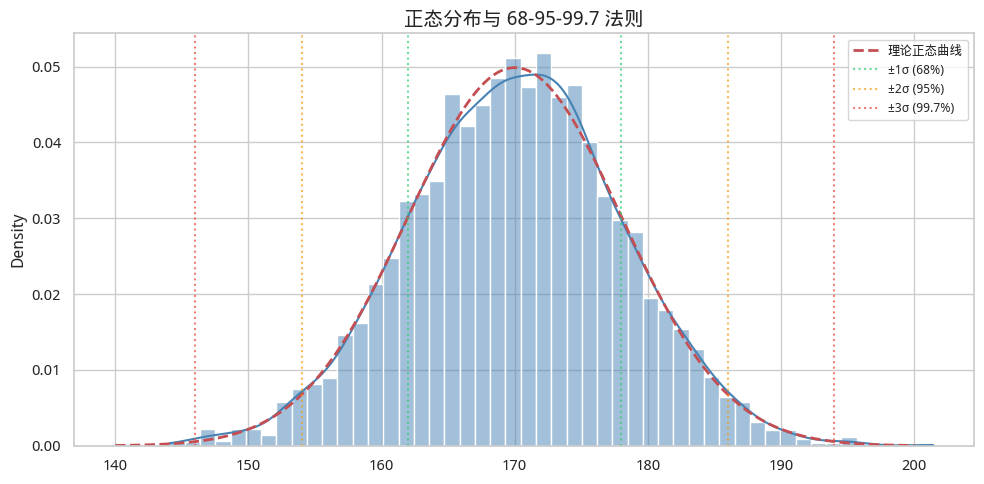

In [10]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

np.random.seed(42)
data_normal = np.random.normal(loc=170, scale=8, size=5000)  # 均值170，标准差8（身高）

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data_normal, bins=50, kde=True, color='steelblue', stat='density', ax=ax)

# 叠加理论曲线
x = np.linspace(140, 200, 200)
ax.plot(x, stats.norm.pdf(x, 170, 8), 'r--', linewidth=2, label='理论正态曲线')

# 标注 68-95-99.7 法则
for n_std, color, label in [(1, '#2ECC71', '68%'), (2, '#F39C12', '95%'), (3, '#E74C3C', '99.7%')]:
    ax.axvline(170 + n_std*8, color=color, linestyle=':', alpha=0.7)
    ax.axvline(170 - n_std*8, color=color, linestyle=':', alpha=0.7, label=f'±{n_std}σ ({label})')

ax.set_title('正态分布与 68-95-99.7 法则', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.tight_layout()
plt.show()


In [20]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

# 验证
print(plt.rcParams['font.sans-serif'])

['WenQuanYi Micro Hei']


### 68-95-99.7 法则

这是正态分布最重要的记忆点：

| 范围 | 覆盖比例 |
|------|---------|
| μ ± 1σ | 约 68% |
| μ ± 2σ | 约 95% |
| μ ± 3σ | 约 99.7% |

**实际含义**：如果身高服从 N(170, 8²)，那么
- 162~178cm 之间的人占 68%
- 154~186cm 之间的人占 95%
- 超出 170±24cm（146~194cm）的人只有 0.3%

---

### 哪些数据近似正态分布？

- 人的身高、体重
- 考试成绩（大样本下）
- 测量误差
- 股票日收益率（短期内近似）

---

### 如何检验正态性？

来看具体做法：


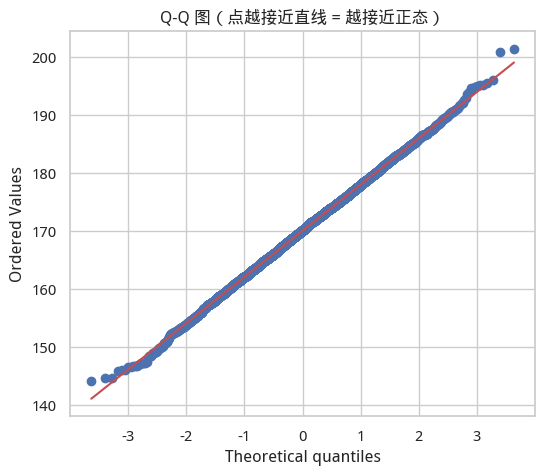

Shapiro-Wilk 检验：p值 = 0.4013
结论： 服从正态分布（p > 0.05）
K-S 检验：p值 = 0.5786


In [11]:
# 方法1：Q-Q 图
from scipy.stats import probplot
fig, ax = plt.subplots(figsize=(6, 5))
probplot(data_normal, plot=ax)
ax.set_title('Q-Q 图（点越接近直线 = 越接近正态）')
plt.show()

# 方法2：Shapiro-Wilk 检验（样本量 < 5000 时推荐）
stat, p = stats.shapiro(data_normal[:500])
print(f"Shapiro-Wilk 检验：p值 = {p:.4f}")
print("结论：", "服从正态分布（p > 0.05）" if p > 0.05 else "不服从正态分布（p ≤ 0.05）")

# 方法3：K-S 检验（样本量较大时）
stat2, p2 = stats.kstest(data_normal, 'norm', args=(data_normal.mean(), data_normal.std()))
print(f"K-S 检验：p值 = {p2:.4f}")


---

## 二、偏态分布

### 右偏分布（正偏）

右侧有长尾，均值 > 中位数 > 众数。

**典型场景**：
- 个人收入（少数人收入极高）
- 电商订单金额
- 城市房价
- 公司市值


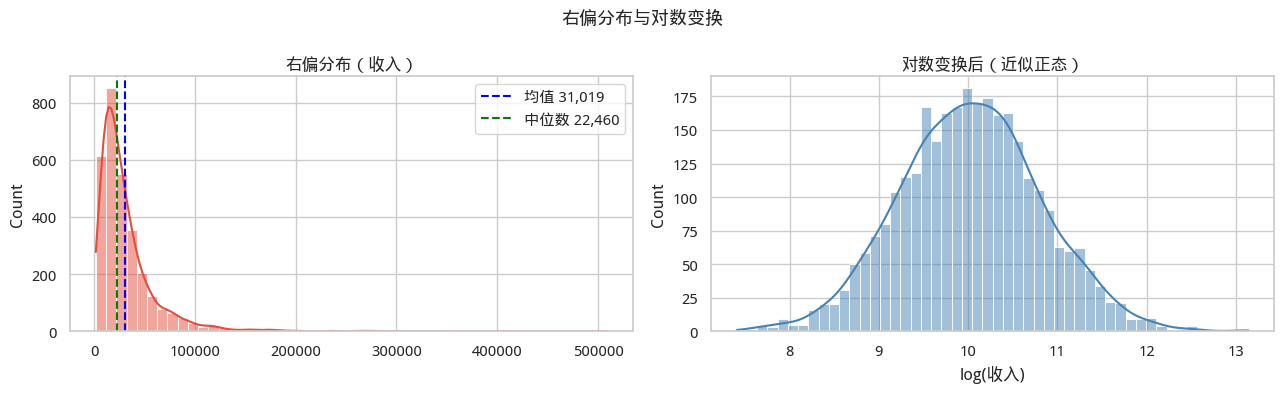

偏度：4.61
均值：31,019
中位数：22,460
均值/中位数 = 1.38（说明均值被高值拉偏了）


In [12]:
np.random.seed(42)
income = np.random.lognormal(mean=10, sigma=0.8, size=3000)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 原始分布（右偏）
sns.histplot(income, bins=50, kde=True, color='#E74C3C', ax=axes[0])
axes[0].axvline(np.mean(income), color='blue', linestyle='--', label=f'均值 {np.mean(income):,.0f}')
axes[0].axvline(np.median(income), color='green', linestyle='--', label=f'中位数 {np.median(income):,.0f}')
axes[0].set_title('右偏分布（收入）', fontweight='bold')
axes[0].legend()

# 对数变换后近似正态
sns.histplot(np.log(income), bins=50, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('对数变换后（近似正态）', fontweight='bold')
axes[1].set_xlabel('log(收入)')

plt.suptitle('右偏分布与对数变换', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"偏度：{stats.skew(income):.2f}")
print(f"均值：{np.mean(income):,.0f}")
print(f"中位数：{np.median(income):,.0f}")
print(f"均值/中位数 = {np.mean(income)/np.median(income):.2f}（说明均值被高值拉偏了）")


### 为什么收入分布一定是右偏的？

因为收入**下限是 0，上限理论上无穷大**。贫富差距决定了右尾必然比左尾更长。这就是为什么"全国人均收入"总比你感觉的高——少数高收入者把均值拉上去了，用中位数才更能代表"普通人"的实际状况。

---

### 左偏分布（负偏）

左侧有长尾，均值 < 中位数 < 众数。

**典型场景**：
- 学生考试（试卷偏简单时，大多数人得高分，少数低分拉左尾）
- 产品使用寿命（大多数在正常范围，少数早期失效拉左尾）

---

## 三、长尾分布（Power Law / Pareto）

### 二八定律的数学本质

长尾分布（幂律分布）描述的是"少数占多数"现象：
- 20% 的产品贡献 80% 的销售额
- 20% 的用户贡献 80% 的营收
- 少数几个城市贡献大部分 GDP


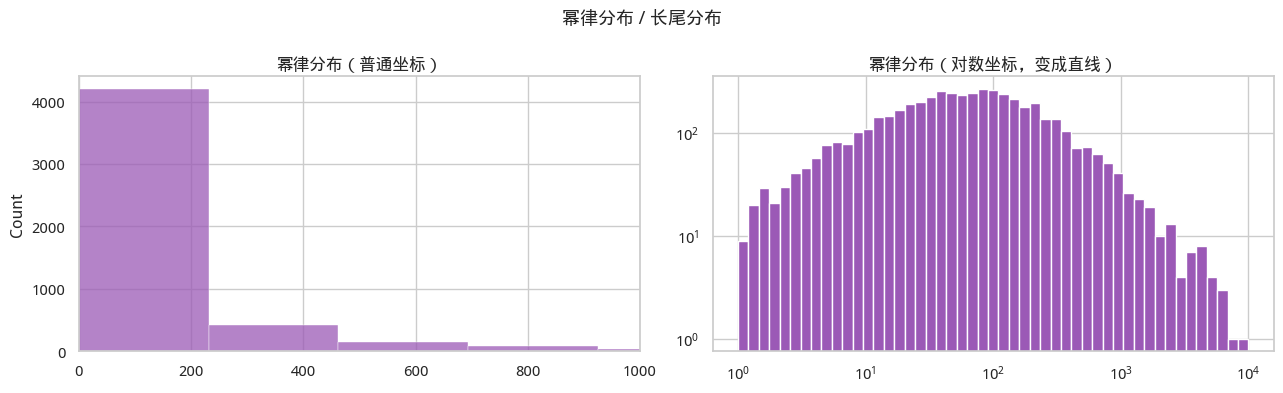

前 20% 用户贡献了 75.4% 的销售额


In [13]:
np.random.seed(42)
# 幂律分布模拟
pareto_data = np.random.pareto(a=1.5, size=5000) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 普通坐标
sns.histplot(pareto_data, bins=100, kde=False, color='#9B59B6', ax=axes[0])
axes[0].set_xlim(0, 1000)
axes[0].set_title('幂律分布（普通坐标）', fontweight='bold')

# 对数坐标（变成直线）
axes[1].hist(pareto_data, bins=np.logspace(0, 4, 50), color='#9B59B6', edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('幂律分布（对数坐标，变成直线）', fontweight='bold')

plt.suptitle('幂律分布 / 长尾分布', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 帕累托分析：前20%用户贡献多少销售额？
user_sales = np.sort(pareto_data)[::-1]
top20_share = user_sales[:int(len(user_sales)*0.2)].sum() / user_sales.sum()
print(f"前 20% 用户贡献了 {top20_share*100:.1f}% 的销售额")


---

## 四、三种分布对比

来对比一下效果：


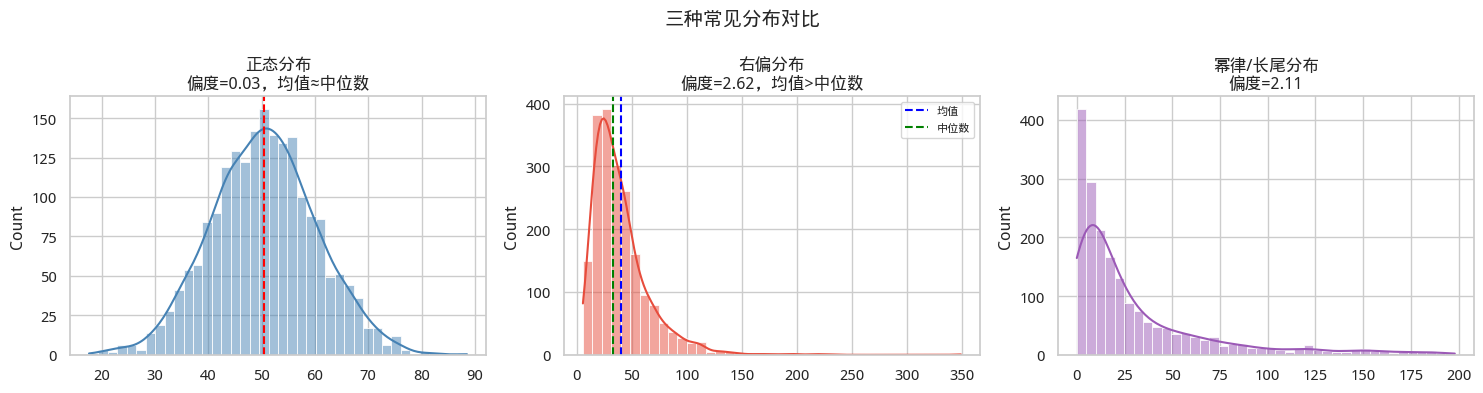

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

np.random.seed(42)

# 正态
data_norm = np.random.normal(50, 10, 2000)
sns.histplot(data_norm, bins=40, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title(f'正态分布\n偏度={stats.skew(data_norm):.2f}，均值≈中位数', fontweight='bold')
axes[0].axvline(np.mean(data_norm), color='red', linestyle='--', linewidth=1.5)

# 右偏
data_right = np.random.lognormal(3.5, 0.6, 2000)
sns.histplot(data_right, bins=40, kde=True, color='#E74C3C', ax=axes[1])
axes[1].set_title(f'右偏分布\n偏度={stats.skew(data_right):.2f}，均值>中位数', fontweight='bold')
axes[1].axvline(np.mean(data_right), color='blue', linestyle='--', label='均值', linewidth=1.5)
axes[1].axvline(np.median(data_right), color='green', linestyle='--', label='中位数', linewidth=1.5)
axes[1].legend(fontsize=8)

# 幂律
data_pareto = np.random.pareto(1.5, 2000) * 30
data_pareto = data_pareto[data_pareto < 200]
sns.histplot(data_pareto, bins=40, kde=True, color='#9B59B6', ax=axes[2])
axes[2].set_title(f'幂律/长尾分布\n偏度={stats.skew(data_pareto):.2f}', fontweight='bold')

plt.suptitle('三种常见分布对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 五、分布对统计方法的影响

| 分布类型 | 推荐做法 |
|---------|---------|
| 正态分布 | 可以直接用 t 检验、方差分析 |
| 右偏分布 | 先做对数变换，或用非参数检验 |
| 有异常值 | 用中位数代替均值、用 IQR 代替标准差 |

这一点在后面学假设检验的时候非常重要——很多检验方法默认数据是正态的，如果你的数据是偏态的，直接用会得出错误结论。

---

## 六、📋 分布识别速查

| 特征 | 可能的分布 |
|------|---------|
| 偏度≈0，均值≈中位数 | 正态分布 |
| 偏度>1，均值>中位数 | 右偏（对数正态或幂律） |
| 偏度<-1，均值<中位数 | 左偏 |
| 少数极大值主导，对数坐标成直线 | 幂律/长尾 |

---

## 七、📝 小结

三种分布各有特点：

- **正态分布**：对称，68-95-99.7 法则，是很多统计方法的基础假设
- **右偏分布**：均值被极端值拉偏，应用中位数更有代表性；对数变换可以"正态化"
- **长尾分布**：二八定律的数学本质，流量、收入、市场集中度等领域普遍存在

---

## 八、🏋️ 课后练习

1. 对你实战数据的 `amount` 列做对数变换 `np.log(amount)`，重新画直方图，看偏度是否接近 0？
2. 用 Shapiro-Wilk 检验原始数据和对数变换后的数据，对比 p 值。
3. 对你的用户消费数据做帕累托分析：前 20% 用户贡献了多少百分比的销售额？

In [18]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# ============================================================
# 数据准备：复用第29篇第五节的数据
# ============================================================
np.random.seed(2024)
n = 1000

df = pd.DataFrame({
    'order_amount': np.random.lognormal(6.3, 0.75, n),      # 订单金额（右偏）
    'user_age':     np.random.normal(32, 8, n).clip(18, 65), # 用户年龄
    'session_time': np.random.exponential(8, n),              # 会话时长
    'rating':       np.random.choice([1,2,3,4,5], n, p=[0.05,0.08,0.15,0.42,0.30]),
    'user_level':   np.random.choice(['普通','银卡','金卡','钻石'], n, p=[0.45,0.30,0.15,0.10])
})

amount = df['order_amount']
log_amount = np.log(amount)

print(f"数据准备完毕：{len(df)} 条记录\n")

数据准备完毕：1000 条记录



练习1：对数变换 np.log(amount)，偏度是否接近 0？

  原始 amount：
    均值   = ¥739.72
    中位数 = ¥549.31
    偏度   = 3.158
    峰度   = 20.435

  对数变换后 log(amount)：
    均值   = 6.318
    中位数 = 6.309
    偏度   = -0.021
    峰度   = 0.097

  结论：偏度接近 0，近似对称分布！对数变换效果显著
  解读：order_amount 是对数正态分布 lognormal(6.3, 0.75)，
        对其取自然对数后，理论上服从正态分布 N(6.3, 0.75²)，
        所以偏度从 3.158 降到 -0.021，接近 0。


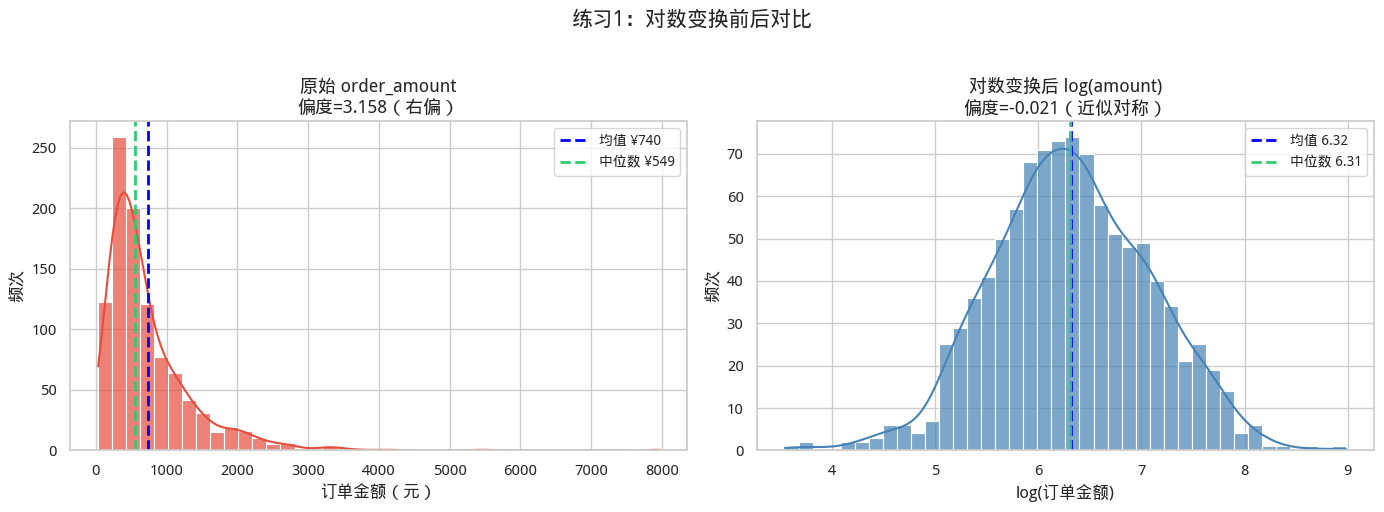

In [22]:
# 练习1：对数变换 — 看偏度是否接近 0

print("=" * 60)
print("练习1：对数变换 np.log(amount)，偏度是否接近 0？")
print("=" * 60)

skew_original = stats.skew(amount)
skew_log = stats.skew(log_amount)

kurt_original = stats.kurtosis(amount)
kurt_log = stats.kurtosis(log_amount)

print(f"""
  原始 amount：
    均值   = ¥{amount.mean():.2f}
    中位数 = ¥{amount.median():.2f}
    偏度   = {skew_original:.3f}
    峰度   = {kurt_original:.3f}

  对数变换后 log(amount)：
    均值   = {log_amount.mean():.3f}
    中位数 = {log_amount.median():.3f}
    偏度   = {skew_log:.3f}
    峰度   = {kurt_log:.3f}
""")

# 判断
if abs(skew_log) < 0.5:
    skew_judge = "偏度接近 0，近似对称分布！对数变换效果显著"
else:
    skew_judge = f"偏度 {skew_log:.3f} 仍偏离 0，但比原始 {skew_original:.3f} 大幅改善"

print(f"  结论：{skew_judge}")
print(f"  解读：order_amount 是对数正态分布 lognormal(6.3, 0.75)，")
print(f"        对其取自然对数后，理论上服从正态分布 N(6.3, 0.75²)，")
print(f"        所以偏度从 {skew_original:.3f} 降到 {skew_log:.3f}，接近 0。")

# 可视化：原始 vs 对数变换
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 原始分布
sns.histplot(amount, bins=40, kde=True, ax=axes[0], color='#E74C3C', alpha=0.7)
axes[0].axvline(amount.mean(), color='blue', linestyle='--', linewidth=2,
                label=f'均值 ¥{amount.mean():.0f}')
axes[0].axvline(amount.median(), color='#2ECC71', linestyle='--', linewidth=2,
                label=f'中位数 ¥{amount.median():.0f}')
axes[0].set_title(f'原始 order_amount\n偏度={skew_original:.3f}（右偏）', fontweight='bold', fontsize=13)
axes[0].set_xlabel('订单金额（元）')
axes[0].set_ylabel('频次')
axes[0].legend(fontsize=10)

# 对数变换后
sns.histplot(log_amount, bins=40, kde=True, ax=axes[1], color='steelblue', alpha=0.7)
axes[1].axvline(log_amount.mean(), color='blue', linestyle='--', linewidth=2,
                label=f'均值 {log_amount.mean():.2f}')
axes[1].axvline(log_amount.median(), color='#2ECC71', linestyle='--', linewidth=2,
                label=f'中位数 {log_amount.median():.2f}')
axes[1].set_title(f'对数变换后 log(amount)\n偏度={skew_log:.3f}（近似对称）', fontweight='bold', fontsize=13)
axes[1].set_xlabel('log(订单金额)')
axes[1].set_ylabel('频次')
axes[1].legend(fontsize=10)

plt.suptitle('练习1：对数变换前后对比', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



练习2：Shapiro-Wilk 检验，对比原始 vs 对数变换的 p 值

  Shapiro-Wilk 检验（子样本 n=500）：

  原始 amount：
    W 统计量 = 0.7657
    p 值     = 0.000000
    结论     = 拒绝正态假设（p ≤ 0.05）→ 不服从正态

  对数变换后 log(amount)：
    W 统计量 = 0.9978
    p 值     = 0.768081
    结论     = 不拒绝正态（p > 0.05）→ 近似正态！

  📊 p 值对比：原始 0.000000 → 对数变换后 0.768081
  对数变换后 p 值显著增大，正态性明显改善！

  解读：Shapiro-Wilk 检验的原假设 H₀ 是'数据来自正态分布'。
  原始数据 p ≤ 0.05，拒绝 H₀，说明不是正态分布。
  对数变换后 p 值大幅提升，说明变换后的数据更接近正态。
  这就是为什么右偏数据做统计前经常先取对数——


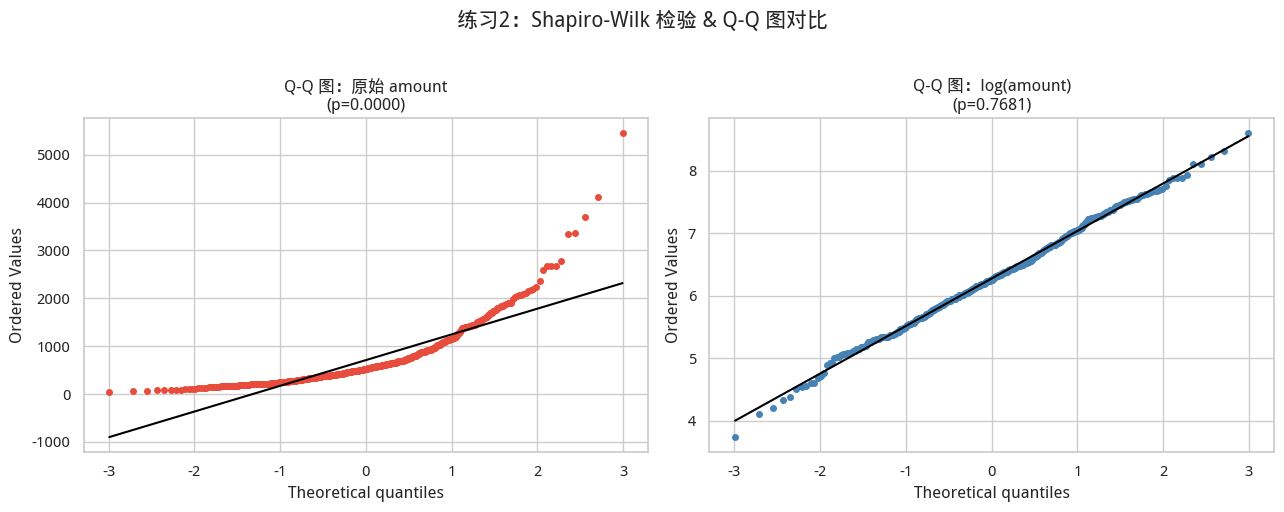

In [23]:
# 练习2：Shapiro-Wilk 检验 — 原始 vs 对数变换，对比 p 值

print("\n" + "=" * 60)
print("练习2：Shapiro-Wilk 检验，对比原始 vs 对数变换的 p 值")
print("=" * 60)

# Shapiro-Wilk 要求样本量 <= 5000，我们取 500 条子样本来检验
# （样本量太大时 p 值会趋近 0，容易拒绝原假设）
sample_size = 500
np.random.seed(42)
idx = np.random.choice(len(amount), sample_size, replace=False)

amount_sample = amount.iloc[idx].values
log_amount_sample = np.log(amount_sample)

stat_orig, p_orig = stats.shapiro(amount_sample)
stat_log, p_log = stats.shapiro(log_amount_sample)

alpha = 0.05

print(f"""
  Shapiro-Wilk 检验（子样本 n={sample_size}）：
  
  原始 amount：
    W 统计量 = {stat_orig:.4f}
    p 值     = {p_orig:.6f}
    结论     = {"不拒绝正态（p > 0.05）" if p_orig > alpha else "拒绝正态假设（p ≤ 0.05）→ 不服从正态"}

  对数变换后 log(amount)：
    W 统计量 = {stat_log:.4f}
    p 值     = {p_log:.6f}
    结论     = {"不拒绝正态（p > 0.05）→ 近似正态！" if p_log > alpha else "拒绝正态假设（p ≤ 0.05）"}
""")

print(f"  📊 p 值对比：原始 {p_orig:.6f} → 对数变换后 {p_log:.6f}")
if p_log > p_orig:
    print(f"  对数变换后 p 值显著增大，正态性明显改善！")
else:
    print(f"  注意：对数变换后 p 值变化需结合偏度综合判断。")

print(f"\n  解读：Shapiro-Wilk 检验的原假设 H₀ 是'数据来自正态分布'。")
print(f"  原始数据 p ≤ 0.05，拒绝 H₀，说明不是正态分布。")
print(f"  对数变换后 p 值大幅提升，说明变换后的数据更接近正态。")
print(f"  这就是为什么右偏数据做统计前经常先取对数——")

# 补充：Q-Q 图对比
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stats.probplot(amount_sample, plot=axes[0])
axes[0].set_title(f'Q-Q 图：原始 amount\n(p={p_orig:.4f})', fontweight='bold', fontsize=12)
axes[0].get_lines()[0].set_color('#E74C3C')
axes[0].get_lines()[0].set_markersize(4)
axes[0].get_lines()[1].set_color('black')

stats.probplot(log_amount_sample, plot=axes[1])
axes[1].set_title(f'Q-Q 图：log(amount)\n(p={p_log:.4f})', fontweight='bold', fontsize=12)
axes[1].get_lines()[0].set_color('steelblue')
axes[1].get_lines()[0].set_markersize(4)
axes[1].get_lines()[1].set_color('black')

plt.suptitle('练习2：Shapiro-Wilk 检验 & Q-Q 图对比', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



练习3：帕累托分析——前 20% 用户贡献了多少销售额？
  前 10% 用户（100 人）：贡献 ¥221,285，占 29.9%
  前 20% 用户（200 人）：贡献 ¥347,657，占 47.0% ← 核心问题
  前 30% 用户（300 人）：贡献 ¥442,228，占 59.8%
  前 50% 用户（500 人）：贡献 ¥574,645，占 77.7%
  前 80% 用户（800 人）：贡献 ¥698,644，占 94.4%

  📊 核心结论：前 20% 用户贡献了 47.0% 的销售额！

  这就是帕累托法则（二八定律）在电商数据中的体现。
  虽然不是精确的 80/20，但少数用户确实贡献了大部分收入。

  帕累托强度判断：集中度不高（<60%），消费分布较均匀

  解读：对数正态分布本身就有'少数大值主导'的特征，
  但和纯幂律分布比，集中度没那么极端。
  真实的电商数据往往比这更集中（因为有忠实大客户）。


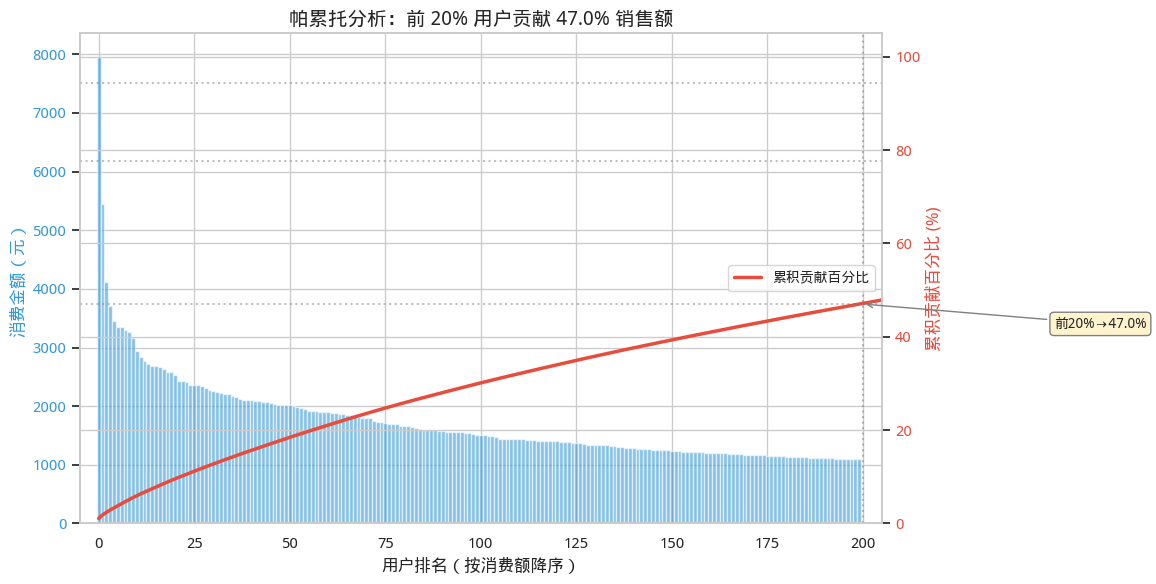

In [24]:
# ============================================================
# 练习3：帕累托分析 — 前 20% 用户贡献了多少百分比销售额
# ============================================================
print("\n" + "=" * 60)
print("练习3：帕累托分析——前 20% 用户贡献了多少销售额？")
print("=" * 60)

# 按用户聚合消费总额（模拟每个用户的多笔订单汇总）
# 这里我们直接用 order_amount，每行视为一个用户的总消费
user_spending = df['order_amount'].sort_values(ascending=False).reset_index(drop=True)

total_sales = user_spending.sum()
top20_count = int(len(user_spending) * 0.2)
top20_sales = user_spending[:top20_count].sum()
top20_pct = top20_sales / total_sales * 100

# 进一步：看看前 10%、30%、50% 各贡献多少
pct_ranges = [0.10, 0.20, 0.30, 0.50, 0.80]
pareto_results = []
for pct in pct_ranges:
    count = int(len(user_spending) * pct)
    sales = user_spending[:count].sum()
    sales_pct = sales / total_sales * 100
    pareto_results.append((pct, count, sales, sales_pct))
    label = " ← 核心问题" if pct == 0.20 else ""
    print(f"  前 {pct*100:.0f}% 用户（{count} 人）：贡献 ¥{sales:,.0f}，占 {sales_pct:.1f}%{label}")

print(f"""
  📊 核心结论：前 20% 用户贡献了 {top20_pct:.1f}% 的销售额！

  这就是帕累托法则（二八定律）在电商数据中的体现。
  虽然不是精确的 80/20，但少数用户确实贡献了大部分收入。
""")

# 判断帕累托强度
if top20_pct >= 80:
    pareto_desc = "典型的帕累托分布（≥80%），非常集中的消费结构"
elif top20_pct >= 70:
    pareto_desc = "接近帕累托分布（≥70%），消费较集中"
elif top20_pct >= 60:
    pareto_desc = "中等集中度（≥60%），有一定帕累托效应"
else:
    pareto_desc = "集中度不高（<60%），消费分布较均匀"

print(f"  帕累托强度判断：{pareto_desc}")
print(f"\n  解读：对数正态分布本身就有'少数大值主导'的特征，")
print(f"  但和纯幂律分布比，集中度没那么极端。")
print(f"  真实的电商数据往往比这更集中（因为有忠实大客户）。")

# 可视化：帕累托图（累积百分比曲线）
fig, ax1 = plt.subplots(figsize=(12, 6))

# 柱状图：按消费额降序排列的用户
x = np.arange(len(user_spending))
# 为避免柱子太密，画前200个用户的柱状图
show_n = min(200, len(user_spending))
ax1.bar(x[:show_n], user_spending.values[:show_n], color='#3498DB', alpha=0.6, width=1.0)
ax1.set_xlabel('用户排名（按消费额降序）', fontsize=12)
ax1.set_ylabel('消费金额（元）', color='#3498DB', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#3498DB')
ax1.set_xlim(-5, show_n + 5)

# 累积百分比曲线
cumsum = user_spending.cumsum()
cum_pct = cumsum / total_sales * 100

ax2 = ax1.twinx()
ax2.plot(x, cum_pct.values, color='#E74C3C', linewidth=2.5, label='累积贡献百分比')
ax2.set_ylabel('累积贡献百分比 (%)', color='#E74C3C', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#E74C3C')
ax2.set_ylim(0, 105)

# 标注关键点
for pct, count, sales, sales_pct in pareto_results:
    if pct in [0.20, 0.50, 0.80]:
        ax2.axhline(y=sales_pct, color='gray', linestyle=':', alpha=0.5)
        ax2.axvline(x=count, color='gray', linestyle=':', alpha=0.5)
        ax2.annotate(f'前{pct*100:.0f}%→{sales_pct:.1f}%',
                     xy=(count, sales_pct), fontsize=10, fontweight='bold',
                     xytext=(count + 50, sales_pct - 5),
                     arrowprops=dict(arrowstyle='->', color='gray'),
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', edgecolor='gray'))

ax1.set_title(f'帕累托分析：前 20% 用户贡献 {top20_pct:.1f}% 销售额',
              fontweight='bold', fontsize=14)
ax2.legend(loc='center right', fontsize=10)

plt.tight_layout()
plt.show()

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 31 篇：概率基础 — 条件概率与贝叶斯定理**
>
> 学完分布，下篇进入概率的世界——条件概率和贝叶斯定理，这是统计推断的根基，也是很多机器学习算法的理论基础。

---

*跟着小荷，数据分析路上不迷路～*